In [13]:
# @title DEPENDENCIES

import pandas as pd

from scipy.stats import mannwhitneyu

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# @title UPLOAD DATASET

from google.colab import files
uploaded = files.upload()

Saving toolwindow_data - toolwindow_data.csv to toolwindow_data - toolwindow_data.csv


In [38]:
# @title Load and Preprocess logs

# LOAD DATASET
df = pd.read_csv('toolwindow_data - toolwindow_data.csv')


df['open_type'] = df['open_type'].replace({'': None})

df['timestamp'] = df['timestamp'].astype(int) // 1000  # seconds
df['user_id'] = df['user_id'].astype(int)
df['event'] = df['event'].astype(str)
df['open_type'] = df['open_type'].astype('string')  # can be None

print("ORIGINAL DATASET:")
print(df.head(20))

# COUNT EVENTS/USERS
num_logs = len(df)
num_opened = (df['event'] == 'opened').sum()
num_closed = (df['event'] == 'closed').sum()
num_manual = ((df['event'] == 'opened') & (df['open_type'] == 'manual')).sum()
num_auto = ((df['event'] == 'opened') & (df['open_type'] == 'auto')).sum()

num_users = df['user_id'].nunique()

print("")
print("COUNTS OF EVENTS/USERS:")
print(f"Number of logs: {num_logs}")
print(f"Number of opened logs: {num_opened}")
print(f"Number of closed logs: {num_closed}")
print(f"Number of manualy opened logs: {num_manual}")
print(f"Number of auto opened logs: {num_auto}")
print("")
print(f"Number of users: {num_users}")


# PREPROCESS DATASET (SORT BY USER AND TIME, OFFSET EACH GROUP, ADD HOUR AND SECONDS COLUMNS)
df_sorted = df.sort_values(by=['user_id', 'timestamp']).reset_index(drop=True)
df_sorted[['hours', 'seconds']] = 0

def make_relative(group):
    first_ts = group['timestamp'].iloc[0]
    relative_sec = group['timestamp'] - first_ts
    hours = (relative_sec // 3600).astype(int)
    seconds = relative_sec % 3600
    group['hours'] = hours
    group['seconds'] = seconds
    return group

df_relative = df_sorted.groupby('user_id').apply(make_relative).reset_index(drop=True)

print("")
print("PREPROCESSED DATASET:")
print(df_relative.head(20))

# COUNT EVENTS PER USER
summary = df.groupby('user_id').agg(
    logs_count=pd.NamedAgg(column='event', aggfunc='count'),
    opened_count=pd.NamedAgg(column='event', aggfunc=lambda x: (x=='opened').sum()),
    closed_count=pd.NamedAgg(column='event', aggfunc=lambda x: (x=='closed').sum()),
    auto_count=pd.NamedAgg(column='open_type', aggfunc=lambda x: (x=='auto').sum()),
    manual_count=pd.NamedAgg(column='open_type', aggfunc=lambda x: (x=='manual').sum())
).reset_index()

print("")
print("NUMBER OF EVENTS PER USER:")
print(summary.head(20))


ORIGINAL DATASET:
     timestamp   event open_type  user_id
0   1752250204  opened    manual        1
1   1751836141  closed      <NA>        2
2   1752304475  closed      <NA>        3
3   1752498934  opened      auto        4
4   1752141991  closed      <NA>        5
5   1752308210  opened      auto        3
6   1752310292  opened      auto        3
7   1752276666  closed      <NA>        6
8   1752158089  opened      auto        5
9   1752174540  opened      auto        7
10  1751903461  opened      auto        8
11  1752185562  opened    manual        9
12  1752149417  closed      <NA>       10
13  1752147744  closed      <NA>       11
14  1752565444  closed      <NA>       12
15  1752250448  closed      <NA>        6
16  1752308784  closed      <NA>        3
17  1751599973  opened      auto       13
18  1751826936  opened    manual        2
19  1751836139  opened    manual        2

COUNTS OF EVENTS/USERS:
Number of logs: 3503
Number of opened logs: 1865
Number of closed logs: 163

/tmp/ipython-input-4207561938.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_relative = df_sorted.groupby('user_id').apply(make_relative).reset_index(drop=True)



PREPROCESSED DATASET:
     timestamp   event open_type  user_id  hours  seconds
0   1751826102  opened      auto        1      0        0
1   1751826746  closed      <NA>        1      0      644
2   1751841258  opened    manual        1      4      756
3   1751849544  closed      <NA>        1      6     1842
4   1751985487  opened    manual        1     44      985
5   1751986623  closed      <NA>        1     44     2121
6   1752250204  opened    manual        1    117     2902
7   1752250204  closed      <NA>        1    117     2902
8   1752250205  opened    manual        1    117     2903
9   1752257432  closed      <NA>        1    119     2930
10  1752843408  opened    manual        1    282     2106
11  1752843421  closed      <NA>        1    282     2119
12  1752843424  opened    manual        1    282     2122
13  1752845073  closed      <NA>        1    283      171
14  1752877044  opened    manual        1    291     3342
15  1752884541  closed      <NA>        1    294 

In [9]:
# @title IRREGULAR LOGS

irregular_rows = []

for user_id, group in df_relative.groupby('user_id'):
    group = group.reset_index(drop=True)
    stack = []
    for idx, row in group.iterrows():
        if row['event'] == 'opened':
            if stack:
                item = stack.pop()
                irregular_rows.append(item)
            stack.append(row)
        elif row['event'] == 'closed':
            if stack:
                stack.pop()
            else:
                irregular_rows.append(row)
    irregular_rows.extend(stack)

df_irregular = pd.DataFrame(irregular_rows).reset_index(drop=True)

print("")
print("IRREGULAR LOGS:")
print(df_irregular.head(20))


# COUNTS OF IRREGULAR LOGS
num_irregular = len(df_irregular)
total_irregular_open = (df_irregular['event'] == 'opened').sum()
total_irregular_close = (df_irregular['event'] == 'closed').sum()
num_irregular_auto = (df_irregular['open_type'] == 'auto').sum()
num_irregular_manual = (df_irregular['open_type'] == 'manual').sum()

print("")
print("COUNTS OF IRREGULAR LOGS:")
print(f"Number of irregular LOGS: {num_irregular}, which is {num_irregular/len(df)*100:.2f}% of the total number of logs")
print(f"Total number of irregular 'opened' events: {total_irregular_open}, which is {total_irregular_open/num_irregular*100:.2f}% of all irregular logs")
print(f"Total number of irregular 'closed' events: {total_irregular_close}, which is {total_irregular_close/num_irregular*100:.2f}% of all irregular logs")
print(f"Total number of irregular 'auto opened' events: {num_irregular_auto}, which is {num_irregular_auto/total_irregular_open*100:.2f}% of all irregular opened logs")
print(f"Total number of irregular 'manual opened' events: {num_irregular_manual}, which is {num_irregular_manual/total_irregular_open*100:.2f}% of all irregular opened logs")


# COUNTS OF IRREGULAR LOGS BY USER
all_users = df_relative['user_id'].unique()

summary_by_user = df_irregular.groupby('user_id').agg(
    total_irregular=pd.NamedAgg(column='event', aggfunc='count'),
    irregular_open=pd.NamedAgg(column='event', aggfunc=lambda x: (x == 'opened').sum()),
    irregular_close=pd.NamedAgg(column='event', aggfunc=lambda x: (x == 'closed').sum()),
    irregular_manual=pd.NamedAgg(column='open_type', aggfunc=lambda x: (x == 'manual').sum()),
    irregular_auto=pd.NamedAgg(column='open_type', aggfunc=lambda x: (x == 'auto').sum())
).reset_index()

print("")
print("COUNTS OF IRREGULAR LOGS BY USER:")
print(summary_by_user.head(20))


# NUMBER OF USERS PER NUMBER OF IRREGULAR LOGS

all_users = df_relative['user_id'].unique()
users_with_irregular = summary_by_user['user_id'].unique()
users_with_zero = set(all_users) - set(users_with_irregular)
num_zero_users = len(users_with_zero)


summary_by_count = (
    summary_by_user.groupby('total_irregular')
    .agg(
        num_users=pd.NamedAgg(column='user_id', aggfunc='count'),
        total_opened=pd.NamedAgg(column='irregular_open', aggfunc='sum'),
        total_closed=pd.NamedAgg(column='irregular_close', aggfunc='sum'),
        manual=pd.NamedAgg(column='irregular_manual', aggfunc='sum'),
        auto=pd.NamedAgg(column='irregular_auto', aggfunc='sum')
    )
    .reset_index()
    .rename(columns={'total_irregular': 'num_irregular'})
)

summary_by_count = pd.concat([
    pd.DataFrame([{
        'num_irregular': 0,
        'num_users': num_zero_users,
        'total_opened': 0,
        'total_closed': 0,
        'manual': 0,
        'auto': 0
    }]),
    summary_by_count
], ignore_index=True).sort_values('num_irregular').reset_index(drop=True)

print("")
print("NUMBER OF USERS PER NUMBER OF IRREGULAR LOGS:")
print("DESCRIPTION: This table shows how many user have made 0/1/2/... irregular logs")
print("")
print(summary_by_count)


IRREGULAR LOGS:
     timestamp   event open_type  user_id  hours  seconds
0   1752317879  opened      auto        3     21     1703
1   1752512831  opened      auto        3     75     2255
2   1752517914  opened      auto        3     77      138
3   1752130885  opened      auto        4     46     2334
4   1752483323  closed      <NA>        4    144     1972
5   1752535753  opened    manual        6    177     2875
6   1752707767  opened      auto        6    225     2089
7   1752300741  opened      auto        7     35      622
8   1753264321  opened      auto        7    302     3002
9   1752492944  opened      auto        8    164      409
10  1751997243  opened    manual       11     18      975
11  1752196602  opened    manual       11     73     2334
12  1752196625  opened      auto       11     73     2357
13  1752496572  opened      auto       11    156     3504
14  1752956232  opened      auto       11    284     2364
15  1752212516  opened    manual       12     25     19

In [32]:
# @title TRANSFORM preprocessed logs

# TRANSFORM PREPROCESSED LOGS (opened-closed pairing)

df_relative = df_relative.sort_values(by=['user_id','timestamp']).reset_index(drop=True)

sessions = []
for user_id, group in df_relative.groupby('user_id'):
    group = group.reset_index(drop=True)
    i = 0
    while i+1 < len(group) :
        open_row = group.iloc[i]
        next_row = group.iloc[i + 1]

        if open_row['event'] == 'opened' and next_row['event'] == 'closed':
            sessions.append({
                'user_id': user_id,
                'open_type': open_row['open_type'],
                'duration_sec': next_row['timestamp'] - open_row['timestamp'],
                'start_hours': open_row['hours'],
                'start_seconds': open_row['seconds']
            })
            i += 2
        else:
            i += 1

df_sessions = pd.DataFrame(sessions)

print("")
print("TRANSFORMED LOGS:")
print(df_sessions.head(30))


# COUNT SESSIONS
num_sessions = len(df_sessions)
manual_count = len(df_sessions[df_sessions['open_type'] == 'manual'])
auto_count = len(df_sessions[df_sessions['open_type'] == 'auto'])

print("")
print("COUNTS OF SESSIONS:")
print(f"Total number of sessions: {num_sessions}")
print(f"Total number of manual sessions: {manual_count}")
print(f"Total number of auto sessions: {auto_count}")


TRANSFORMED LOGS:
    user_id open_type  duration_sec  start_hours  start_seconds
0         1      auto           644            0              0
1         1    manual          8286            4            756
2         1    manual          1136           44            985
3         1    manual             0          117           2902
4         1    manual          7227          117           2903
5         1    manual            13          282           2106
6         1    manual          1649          282           2122
7         1    manual          7497          291           3342
8         1    manual          2404          355            338
9         2      auto            58            0              0
10        2    manual           313            0            210
11        2    manual             0            0            524
12        2    manual             1           45           2156
13        2    manual             3           47           1595
14        2    manual

📊 AUTO durations (sec):
count       992.0
mean       6178.8
std       28314.0
min           0.0
25%          35.8
50%         185.0
75%        1196.2
max      409874.0

📊 MANUAL durations (sec):
count       595.0
mean       1505.3
std       10951.2
min           0.0
25%           2.0
50%          11.0
75%         135.5
max      180918.0

NUMBER OF OUTLIERS AND PERCENTAGE OF ALL SESSIONS PER TYPE:
Auto sessions: 154 outliers (15.52% of all auto sessions)
Manual sessions: 100 outliers (16.81% of all manual sessions)



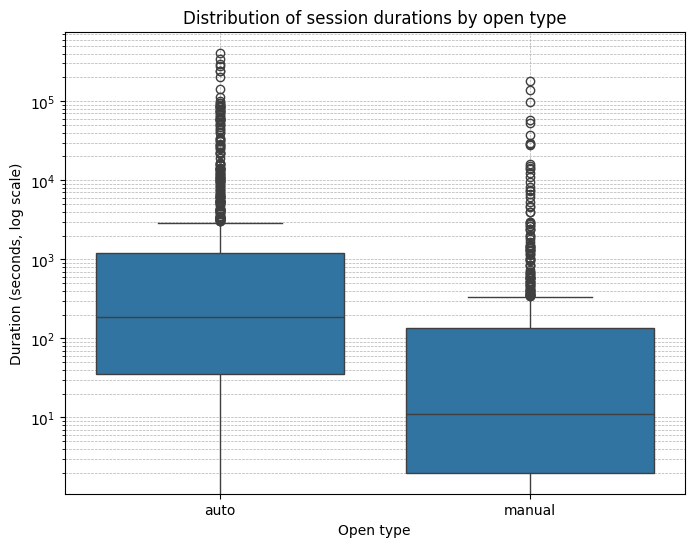

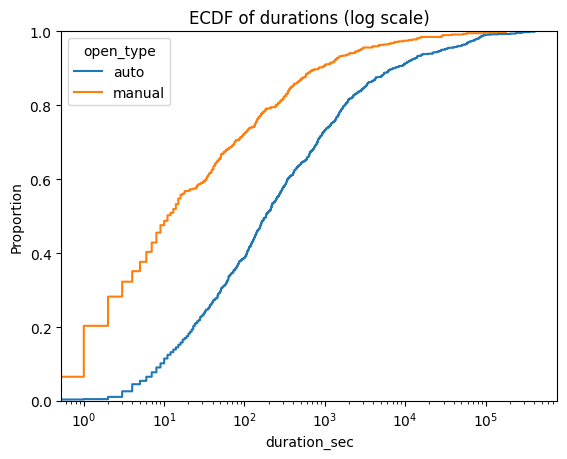

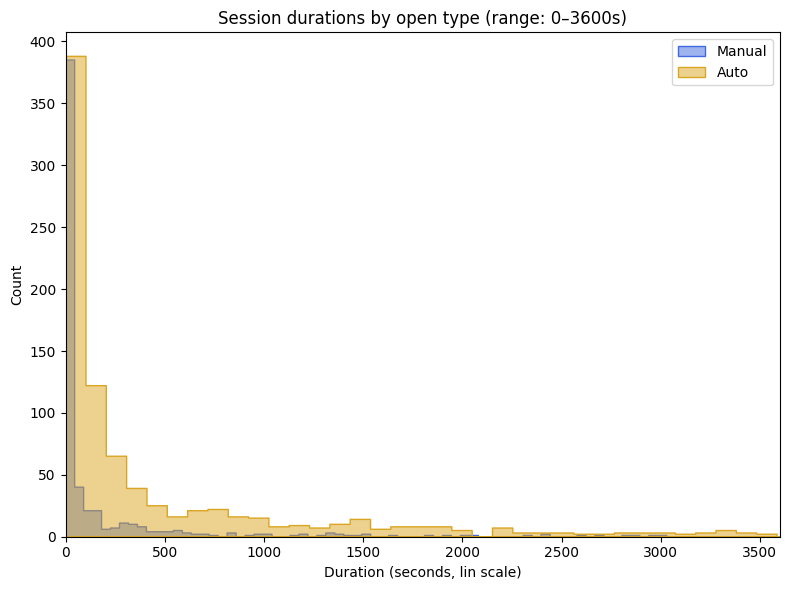

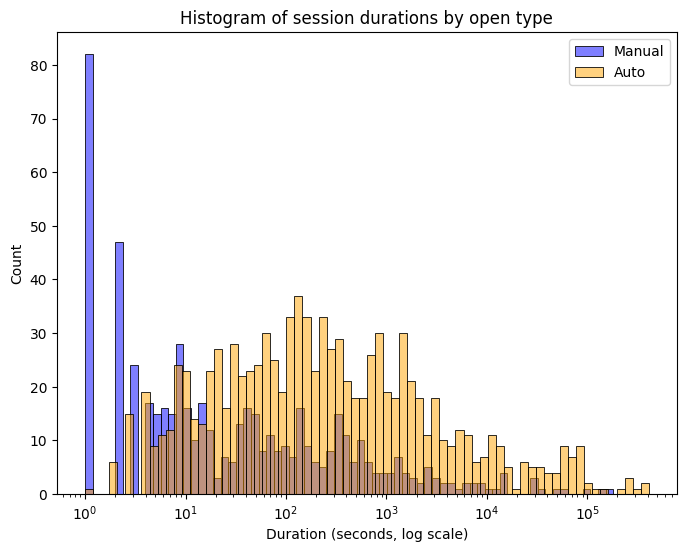



Mann-Whitney U test:
U statistic: 442039.50, p-value: 4.5245e-62
There is a statistically significant difference between auto and manual durations (p < 0.05).


In [36]:
# @title ANALYSE AND VISUALIZE SESSIONS

# Stats for auto and manual sessions
auto_durations = df_sessions[df_sessions['open_type']=='auto']['duration_sec']
manual_durations = df_sessions[df_sessions['open_type']=='manual']['duration_sec']

auto_stats = auto_durations.describe(percentiles=[0.25, 0.5, 0.75]).apply(lambda x: f"{x:.1f}")
manual_stats = manual_durations.describe(percentiles=[0.25, 0.5, 0.75]).apply(lambda x: f"{x:.1f}")

print("📊 AUTO durations (sec):")
print(auto_stats.to_string())
print("\n📊 MANUAL durations (sec):")
print(manual_stats.to_string())


# COUNT OULIERS FOR EACH SESSION TYPE
def count_outliers(df, col='duration_sec', group_col='open_type'):
    results = {}
    for open_type, group in df.groupby(group_col):
        q1 = group[col].quantile(0.25)
        q3 = group[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outliers = group[(group[col] < lower) | (group[col] > upper)]
        results[open_type] = len(outliers)
    return results

outlier_counts = count_outliers(df_sessions)
total_counts = df_sessions.groupby('open_type')['duration_sec'].count().to_dict()

print("")
print("NUMBER OF OUTLIERS AND PERCENTAGE OF ALL SESSIONS PER TYPE:")
for open_type, count in outlier_counts.items():
    total = total_counts.get(open_type, 0)
    percent = 100 * count / total if total > 0 else 0
    print(f"{open_type.capitalize()} sessions: {count} outliers ({percent:.2f}% of all {open_type} sessions)")
print("")


# BOXPLOT FOR AUTO/MANUAL SESSIONS
df_plot = df_sessions[df_sessions['open_type'].isin(['manual','auto'])]

plt.figure(figsize=(8,6))
sns.boxplot(x='open_type', y='duration_sec', data=df_plot)

plt.yscale('log')
plt.ylabel('Duration (seconds, log scale)')
plt.xlabel('Open type')
plt.title('Distribution of session durations by open type')
plt.grid(True, which="both", ls="--", lw=0.5)
plt.show()
print("")


# ECDF FOR AUTO/MANUAL SESSIONS

sns.ecdfplot(data=df_plot, x="duration_sec", hue="open_type")
plt.xscale('log')
plt.title('ECDF of durations (log scale)')
plt.show()
print("")


# HISTOGRAM FOR AUTO/MANUAL SESSIONS

plt.figure(figsize=(8, 6))
sns.histplot(manual_durations, color='royalblue', label='Manual', bins=4000, alpha=0.5, element='step')
sns.histplot(auto_durations, color='goldenrod', label='Auto', bins=4000, alpha=0.5, element='step')

plt.xlim(0, 3600)
plt.xlabel('Duration (seconds, lin scale)')
plt.ylabel('Count')
plt.title('Session durations by open type (range: 0–3600s)')
plt.legend()
plt.tight_layout()
plt.show()
print("")

plt.figure(figsize=(8,6))
sns.histplot(manual_durations, color='blue', label='Manual', bins=70, log_scale=True, alpha=0.5)
sns.histplot(auto_durations, color='orange', label='Auto', bins=70, log_scale=True, alpha=0.5)

plt.xlabel('Duration (seconds, log scale)')
plt.ylabel('Count')
plt.title('Histogram of session durations by open type')
plt.legend()
plt.show()
print("")


# Mann-Whitney U test
stat, p_value = mannwhitneyu(auto_durations, manual_durations, alternative='two-sided')

print("")
print("Mann-Whitney U test:")
print(f"U statistic: {stat:.2f}, p-value: {p_value:.4e}")

if p_value < 0.05:
    print("There is a statistically significant difference between auto and manual durations (p < 0.05).")
else:
    print("There is no statistically significant difference between auto and manual durations (p ≥ 0.05).")